# DH Final Diagnostics — 20260608 (post-2000 final grid)

Final-selection notebook for the **256-config final grid** at
`02-evaluate/20260608_final/` (predictions ON). Fork of
`20260515/dh_final_diagnostics_post2000.ipynb`, repointed at the new
re-fit-pipeline run.

The storm-level machinery here — `mid` reconstruction → per-row prediction
loaders → drop-top-N trimmed calibration → IS/OOS divergence → picking table —
is the point of this stage: it arbitrates the winner where the aggregate
ranking can't. (The refined ranking favoured configs pinned at the
calibration-gate floor, i.e. heavy aggregate under-prediction; trimmed,
storm-level calibration is what separates them.)

**Convergence gate removed:** the re-fit-in-evaluate pipeline has no fit stage
and writes no per-component `.json` sidecars, so that gate (present in the
20260517 version) is dropped.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from idd_tc_mortality.select.model_query import ModelQuery
from idd_tc_mortality.select.model_selection import (
    CONFIG_COLS,
    DEFAULT_METRICS,
    CALIBRATION_METRICS,
    prepare_rankings_df,
    borda_rank,
    pareto_frontier,
    topsis_rank,
    pairwise_dominance_summary,
    cluster_configurations,
    winner_profile,
    kendall_tau_heatmap,
)
from idd_tc_mortality.viz.stage_plots import StagePlotter

# Reuse the qmd's helper module for shared heatmap / winner-panel plots.
sys.path.insert(0, str(Path('..').resolve() / 'reports'))
import _helpers as H

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.options.display.max_columns = 80
pd.options.display.width = 160

## Paths

Edit the dates to point at the refined run you want to inspect.

In [2]:
ROOT      = Path('/mnt/team/idd/pub/idd_tc_mortality')
EVAL_DATE = '20260608_final'   # 256-config final-grid evaluate dir (predictions ON)
DATA_DATE = '20260608'         # post-2000 input.parquet (years >= 2000)

RESULTS_PATH   = ROOT / '02-evaluate' / EVAL_DATE / 'dh_results.parquet'
EVAL_DIR       = ROOT / '02-evaluate' / EVAL_DATE
DATA_PATH      = ROOT / '00-data'     / DATA_DATE / 'input.parquet'
MODEL_PRED_DIR = EVAL_DIR / 'model_predictions'
# Re-fit pipeline writes the manifest into the evaluate dir (no separate fit stage).
MANIFEST_PATH  = EVAL_DIR / 'manifest.json'

for p in (RESULTS_PATH, EVAL_DIR, DATA_PATH, MODEL_PRED_DIR, MANIFEST_PATH):
    assert p.exists(), f'Missing: {p}'
print('All paths resolve.')
print(f'  model_predictions parquets: {len(list(MODEL_PRED_DIR.glob("*.parquet")))}')


All paths resolve.
  model_predictions parquets: 1536


## Load

In [3]:
dh_results = pd.read_parquet(RESULTS_PATH)
data       = pd.read_parquet(DATA_PATH)

print(f'dh_results : {dh_results.shape[0]:,} rows × {dh_results.shape[1]} cols')
print(f'training   : {data.shape[0]:,} rows × {data.shape[1]} cols')
print(f'fold_tags  : {dh_results["fold_tag"].value_counts().to_dict()}')
print(f'configs    : {dh_results.groupby(CONFIG_COLS, dropna=False).ngroups:,} unique')
print(f'thresholds : {sorted(dh_results["threshold_quantile"].unique())}')

dh_results : 1,536 rows × 252 cols
training   : 1,903 rows × 13 cols
fold_tags  : {'insample': 256, 'oos_seed0': 256, 'oos_seed1': 256, 'oos_seed2': 256, 'oos_seed3': 256, 'oos_seed4': 256}
configs    : 256 unique
thresholds : [np.float64(0.7)]


## Build the rankings dataframe

`prepare_rankings_df(..., subset='oos')` gives one row per config with OOS
metrics averaged across seeds. This is the canonical input to all ranking
methods below.

Then we cull: drop configs with any non-finite OOS metric (failed folds)
and configs outside the calibration gate. Tighten or loosen the cull as
needed.

In [4]:
df_oos = prepare_rankings_df(dh_results, subset='oos')
print(f'{len(df_oos):,} configurations before any cull')


256 configurations before any cull


In [5]:
print(f'Before cull: {len(df_oos):,} configs')

# Drop configs with any non-finite OOS metric (failed folds).
oos_numeric = [c for c in df_oos.columns
               if c.endswith('_oos') and pd.api.types.is_numeric_dtype(df_oos[c])]
finite_mask = np.isfinite(df_oos[oos_numeric].to_numpy()).all(axis=1)
n_failed = int((~finite_mask).sum())
df_oos = df_oos[finite_mask].copy()
print(f'After non-finite cull: {len(df_oos):,} configs ({n_failed:,} dropped as failures)')

# Asymmetric calibration gate — under-prediction (mega-event honesty)
# allowed; over-prediction (compensating bulk overpred) capped tighter.
# See preliminary_decisions_post2000.qmd §Scope.
RATIO_BOUNDS = (0.05, 1.1)
df_oos = df_oos[df_oos['full_pred_obs_ratio_oos'].between(*RATIO_BOUNDS)].copy()
print(f'After calibration gate [{RATIO_BOUNDS[0]}, {RATIO_BOUNDS[1]}]: '
      f'{len(df_oos):,} configs')

print('\nPost-cull count per threshold:')
print(df_oos['threshold_quantile'].value_counts().sort_index().to_string())

Before cull: 256 configs
After non-finite cull: 256 configs (0 dropped as failures)
After calibration gate [0.05, 1.1]: 256 configs

Post-cull count per threshold:
threshold_quantile
0.7    256


### Convergence gate — N/A for the re-fit pipeline

The 20260517 version scanned per-component `{component_id}.json` sidecars in the
fit directory for an IRLS/optimiser `converged` flag. The re-fit-in-evaluate
pipeline has **no fit stage and writes no sidecars** — components are re-fit
in-memory by the evaluate worker and convergence is not persisted to
`dh_results.parquet`. So this gate is dropped; `df_oos` after the calibration
gate above is the candidate pool that feeds the storm-level diagnostics.


## Per-rule winner trajectories

Same diagnostic as the preliminary qmd's Threshold section, on the refined
survivor pool. For each threshold, six configs are identified — the one
that wins at coverage level 1, 5, 10, 15, 20 (argmax of
`full_coverage_rate_L_oos`), and the one that wins on the mean across all
20 levels — and their full 1..20 trajectories are plotted. Each level-winner
gets a dot at the level where it was picked.

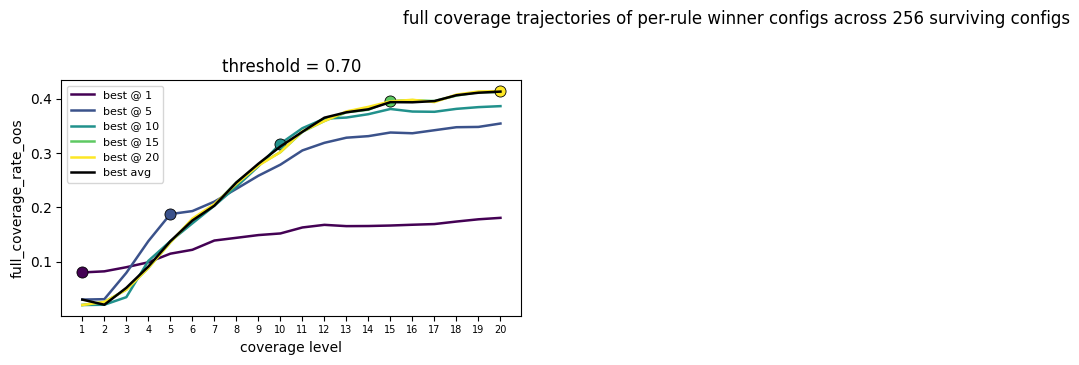


Winner configs per (threshold, rule):
 threshold      rule s1_family s1_exposure_mode                                                               s1_cov s2_family s2_exposure_mode                                                               s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov  tail_family tail_exposure_mode                                                                tail_cov
       0.7  best @ 1     logit             free  {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true} scaled_logit               free {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}      weibull               free  {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}
       0.7  best @ 5     logit             free  {"basin": true, "is_island": true, "sdi": true, "wind_speed": true}     

In [6]:
winner_records = H.threshold_winner_panels(df_oos)
plt.show()

print('\nWinner configs per (threshold, rule):')
print(winner_records.to_string(index=False))

## Per-row diagnostics — `mid` reconstruction

`dh_results.parquet` stores spec attributes (family, exposure_mode, cov)
but not the MD5 model_id used as the filename prefix in
`model_predictions/`. Rebuild it once via a lookup against the refined
manifest, then attach as a `mid` column on `df_oos`.

The refined-final round reused the refined fits, so the right manifest
is the one at `01-refined/20260517/manifest.json` (set above as
`MANIFEST_PATH`).

In [7]:
import json
from idd_tc_mortality.cache import model_id as compute_model_id

manifest = json.loads(MANIFEST_PATH.read_text())

# Build a lookup: (component, threshold, family, exposure_mode, cov_str) -> full spec dict.
# threshold is None for s1. cov_str is the JSON of covariate_combo with sort_keys=True.
spec_lookup: dict[tuple, dict] = {}
for cid, spec in manifest.items():
    if not isinstance(spec, dict):
        continue
    if spec.get('fold_tag', 'is') != 'is':
        continue
    cov_str = json.dumps(spec.get('covariate_combo', {}), sort_keys=True)
    key = (
        spec.get('component'),
        spec.get('threshold_quantile'),  # None for s1
        spec.get('family'),
        spec.get('exposure_mode'),
        cov_str,
    )
    spec_lookup[key] = spec


def _row_to_mid(row: pd.Series) -> str:
    """Look up the 4 component specs for this DH row, compute the model_id hash."""
    q = row['threshold_quantile']
    s1 = spec_lookup[('s1',   None, row['s1_family'],   row['s1_exposure_mode'],   row['s1_cov'])]
    s2 = spec_lookup[('s2',   q,    row['s2_family'],   row['s2_exposure_mode'],   row['s2_cov'])]
    bk = spec_lookup[('bulk', q,    row['bulk_family'], row['bulk_exposure_mode'], row['bulk_cov'])]
    tl = spec_lookup[('tail', q,    row['tail_family'], row['tail_exposure_mode'], row['tail_cov'])]
    return compute_model_id(s1, s2, bk, tl)


df_oos['mid'] = df_oos.apply(_row_to_mid, axis=1)
print(f'mid attached. {df_oos["mid"].nunique()} unique mids across {len(df_oos)} configs.')

# Sanity check: at least one mid's files should exist on disk.
test_mid = df_oos['mid'].iloc[0]
is_path  = MODEL_PRED_DIR / f'{test_mid}_insample_predictions.parquet'
print(f'sample IS pred file exists: {is_path.exists()} ({is_path.name})')


mid attached. 256 unique mids across 256 configs.
sample IS pred file exists: True (7dbf251bad1f46546be3708689268710_insample_predictions.parquet)


## Per-config prediction loader

Each config in the refined-final pool has 6 per-row prediction parquets:
- 1 IS  (`<mid>_insample_predictions.parquet`)
- 5 OOS seeds (`<mid>_oos_seed{0..4}_predictions.parquet`)

The loaders below join each prediction frame back to `input.parquet` by
row position so the storm/year/location metadata travels alongside
`predicted_rate`.

In [8]:
# Aliased to match the loader's expectation.
obs = data

def _join_input(pred_df: pd.DataFrame) -> pd.DataFrame:
    """Attach input.parquet's metadata columns to a per-row prediction frame."""
    if len(pred_df) != len(obs):
        raise ValueError(
            f'prediction row count {len(pred_df)} != input row count {len(obs)}'
        )
    out = obs.copy()
    out['predicted_rate'] = pred_df['predicted_rate'].values
    for col in ('heldout_fold_tag', 'threshold_rate', 'fold_tag'):
        if col in pred_df.columns:
            out[col] = pred_df[col].values
    return out


def load_is_pred(mid: str) -> pd.DataFrame:
    p = MODEL_PRED_DIR / f'{mid}_insample_predictions.parquet'
    return _join_input(pd.read_parquet(p))


def load_oos_pred(mid: str) -> pd.DataFrame:
    """Load all 5 OOS-seed predictions, joined to input metadata, with `seed` col."""
    frames = []
    for seed in range(5):
        p = MODEL_PRED_DIR / f'{mid}_oos_seed{seed}_predictions.parquet'
        if not p.exists():
            continue
        joined = _join_input(pd.read_parquet(p))
        joined['seed'] = seed
        frames.append(joined)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


## Drop-top-N trimmed calibration ratio

For every config in the post-cull pool, recompute the obs/pred ratio
after dropping the top-N storms by observed deaths. Sweep N ∈
{0, 5, 10, 25}. Three column families produced:

- `trim_n=*_is`         — IS ratio per N
- `trim_n=*_oos_mean`   — OOS ratio, mean across 5 seeds
- `trim_n=*_oos_median` — OOS ratio, median across 5 seeds

A config whose `trim_n=0` is near 1 but `trim_n=5` is far from 1 (or
vice versa) is exposed as either mega-event-only or bulk-only
calibrated. We want configs that stay near 1 across the N sweep.

In [9]:
def trimmed_full_ratio_is(mid: str, drop_top_n: int) -> float:
    is_df = load_is_pred(mid)
    if is_df.empty:
        return float('nan')
    is_df['pred_deaths'] = is_df['predicted_rate'] * is_df['exposed']
    per_storm = (is_df.groupby('storm_id', as_index=False)
        .agg(obs=('deaths', 'sum'), pred=('pred_deaths', 'sum'))
        .sort_values('obs', ascending=False))
    keep = per_storm.iloc[drop_top_n:]
    denom = keep['obs'].sum()
    return float(keep['pred'].sum() / denom) if denom > 0 else float('nan')


def trimmed_full_ratio_oos(mid: str, drop_top_n: int) -> dict:
    """Returns dict of per-seed, mean, and median trimmed ratios. NaN-safe."""
    oos = load_oos_pred(mid)
    if oos.empty or 'predicted_rate' not in oos.columns:
        return {'mean': float('nan'), 'median': float('nan'), 'per_seed': []}

    out = {'per_seed': []}
    oos['pred_deaths'] = oos['predicted_rate'] * oos['exposed']
    for seed, sdf in oos.groupby('seed'):
        per_storm = (sdf
            .groupby('storm_id', as_index=False)
            .agg(obs=('deaths', 'sum'), pred=('pred_deaths', 'sum'))
            .sort_values('obs', ascending=False))
        keep = per_storm.iloc[drop_top_n:]  # drop top-N by observed
        denom = keep['obs'].sum()
        ratio = float(keep['pred'].sum() / denom) if denom > 0 else float('nan')
        out['per_seed'].append(ratio)
    out['mean']   = float(np.nanmean(out['per_seed']))
    out['median'] = float(np.nanmedian(out['per_seed']))
    return out


# Sweep over all 96 configs in the post-cull pool. ~1 sec/config of NFS reads;
# expected ~2 min wall.
N_SWEEP = [0, 5, 10, 25]
records = []

for i, (_, row) in enumerate(df_oos.iterrows(), start=1):
    mid = row['mid']
    for n in N_SWEEP:
        r_oos = trimmed_full_ratio_oos(mid, drop_top_n=n)
        r_is  = trimmed_full_ratio_is(mid, drop_top_n=n)
        records.append({
            'mid': mid,
            'drop_top_n': n,
            'ratio_mean':   r_oos['mean'],
            'ratio_median': r_oos['median'],
            'ratio_is':     r_is,
        })
    if i % 10 == 0 or i == len(df_oos):
        print(f'  trimmed-ratio: {i}/{len(df_oos)} configs done')


  trimmed-ratio: 10/256 configs done
  trimmed-ratio: 20/256 configs done
  trimmed-ratio: 30/256 configs done
  trimmed-ratio: 40/256 configs done
  trimmed-ratio: 50/256 configs done
  trimmed-ratio: 60/256 configs done
  trimmed-ratio: 70/256 configs done
  trimmed-ratio: 80/256 configs done
  trimmed-ratio: 90/256 configs done
  trimmed-ratio: 100/256 configs done
  trimmed-ratio: 110/256 configs done
  trimmed-ratio: 120/256 configs done
  trimmed-ratio: 130/256 configs done
  trimmed-ratio: 140/256 configs done
  trimmed-ratio: 150/256 configs done
  trimmed-ratio: 160/256 configs done
  trimmed-ratio: 170/256 configs done
  trimmed-ratio: 180/256 configs done
  trimmed-ratio: 190/256 configs done
  trimmed-ratio: 200/256 configs done
  trimmed-ratio: 210/256 configs done
  trimmed-ratio: 220/256 configs done
  trimmed-ratio: 230/256 configs done
  trimmed-ratio: 240/256 configs done
  trimmed-ratio: 250/256 configs done
  trimmed-ratio: 256/256 configs done


In [10]:
recs = pd.DataFrame(records)

trim_df_mean   = recs.pivot(index='mid', columns='drop_top_n', values='ratio_mean')
trim_df_median = recs.pivot(index='mid', columns='drop_top_n', values='ratio_median')
trim_df_is     = recs.pivot(index='mid', columns='drop_top_n', values='ratio_is')

trim_df_mean.columns   = [f'trim_n={n}_oos_mean'   for n in trim_df_mean.columns]
trim_df_median.columns = [f'trim_n={n}_oos_median' for n in trim_df_median.columns]
trim_df_is.columns     = [f'trim_n={n}_is'         for n in trim_df_is.columns]

# Merge all three column families onto df_oos by mid.
df_oos = (df_oos
    .merge(trim_df_is,     left_on='mid', right_index=True, how='left')
    .merge(trim_df_mean,   left_on='mid', right_index=True, how='left')
    .merge(trim_df_median, left_on='mid', right_index=True, how='left')
)

trim_df = trim_df_median   # canonical: matches the median-aggregation of the screening gate
print(f'Trim columns merged onto df_oos. Total cols now: {df_oos.shape[1]}')


Trim columns merged onto df_oos. Total cols now: 145


## IS / OOS divergence

For each config and each N, `is_oos_ratio_n=*` = `trim_n=*_is` /
`trim_n=*_oos_median`. Close to 1 = IS calibration carries to OOS
without surprises. Far from 1 = the config calibrates IS by being
right on the storms it overfits to, and that doesn't generalise.

Reported per-config:
- `is_oos_max_log_dev`  — max |log(is/oos)| across the N sweep
- `is_oos_mean_log_dev` — mean |log(is/oos)| across the N sweep

In [11]:
for n in N_SWEEP:
    df_oos[f'is_oos_ratio_n={n}'] = (
        df_oos[f'trim_n={n}_is'] / df_oos[f'trim_n={n}_oos_median']
    )

ratio_cols = [f'is_oos_ratio_n={n}' for n in N_SWEEP]
df_oos['is_oos_max_log_dev']  = np.abs(np.log(df_oos[ratio_cols])).max(axis=1)
df_oos['is_oos_mean_log_dev'] = np.abs(np.log(df_oos[ratio_cols])).mean(axis=1)

# Same diagnostic on the trim-OOS-median itself (max |log(trim_median)| across N).
log_dev = np.abs(np.log(df_oos[[f'trim_n={n}_oos_median' for n in N_SWEEP]]))
df_oos['oos_median_max_log_dev']  = log_dev.max(axis=1)
df_oos['oos_median_mean_log_dev'] = log_dev.mean(axis=1)
print('IS/OOS divergence columns attached.')


IS/OOS divergence columns attached.


In [12]:
df_oos['trim_n=25_oos_median'].max()

np.float64(1.2215164638794234)

## Pick your own metrics

The 13-metric `DEFAULT_METRICS` is just a starting point. Edit the dict
below — comment / uncomment lines — to define the set used downstream.
Both the Kendall heatmap and the ranking step use whatever you set as
`metrics_present` and `calib_present` here.

Direction:
- `'lower'`  → smaller is better
- `'higher'` → larger is better
- `'calib'`  → closer to 1.0 is better (handled separately by the ranking API)

In [13]:
metrics_to_use = {
    # ---- S1 (binary: P(deaths >= 1)) ----
    's1_auroc_oos':                  'higher',
    # 's1_brier_oos':                'lower',
    # 's1_fpr_oos':                  'lower',
    # 's1_fnr_oos':                  'lower',

    # ---- S2 (binary: P(rate >= thresh | deaths >= 1)) ----
    's2_auroc_oos':                  'higher',
    # 's2_brier_oos':                'lower',

    # ---- Bulk (regression on rate < thresh) ----
    'bulk_mae_rate_oos':             'lower',
    # 'bulk_rmse_rate_oos':          'lower',
    # 'bulk_cor_rate_oos':           'higher',

    # ---- Tail (regression on rate >= thresh) ----
    # 'tail_mae_rate_oos':             'lower',
    # 'tail_rmse_rate_oos':          'lower',
    # 'tail_cor_rate_oos':           'higher',

    # ---- Full (unconditional E[rate], applies to every row) ----
    'full_mae_rate_oos':             'lower',
    # 'full_rmse_rate_oos':            'lower',
    # 'full_cor_rate_oos':             'higher',
    # 'full_zero_acc_oos':             'higher',
    # 'full_pred_obs_ratio_oos':       'calib',
    'full_coverage_rate_20_oos':     'higher',
    'full_coverage_count_20_oos':     'higher',

    # ---- Forward (stage-conditional aggregate) ----
    # 'fwd_mae_rate_oos':              'lower',
    #'fwd_pred_obs_ratio_oos':        'calib',
    'fwd_coverage_rate_20_oos':      'higher',
    'fwd_coverage_count_20_oos':      'higher',

    # ---- IS/OOS divergence (diagnostic, not a selection metric) ----
    'trim_n=10_oos_median':         'calib',
    'trim_n=10_is':         'calib',
}

calib_present   = [k for k, v in metrics_to_use.items()
                   if v == 'calib' and k in df_oos.columns]
metrics_present = {k: v for k, v in metrics_to_use.items()
                   if v != 'calib' and k in df_oos.columns}

print(f'Active rank metrics ({len(metrics_present)}):')
for m, d in metrics_present.items():
    print(f'  {m:35s}  {d}')
print(f'\nActive calibration metrics ({len(calib_present)}):')
for c in calib_present:
    print(f'  {c}  (closer to 1.0)')

missing = [k for k in metrics_to_use if k not in df_oos.columns]
if missing:
    print(f'\n[note] {len(missing)} requested metrics not in df_oos (skipped): {missing}')

Active rank metrics (8):
  s1_auroc_oos                         higher
  s2_auroc_oos                         higher
  bulk_mae_rate_oos                    lower
  full_mae_rate_oos                    lower
  full_coverage_rate_20_oos            higher
  full_coverage_count_20_oos           higher
  fwd_coverage_rate_20_oos             higher
  fwd_coverage_count_20_oos            higher

Active calibration metrics (2):
  trim_n=10_oos_median  (closer to 1.0)
  trim_n=10_is  (closer to 1.0)


## Kendall τ — metric correlation

Rank correlation between metrics on the culled candidate pool. Tightly
correlated metrics (high τ) are redundant for ranking purposes; an
uncorrelated metric adds independent information.

Computing rank correlations on 256 configs × 8 metrics


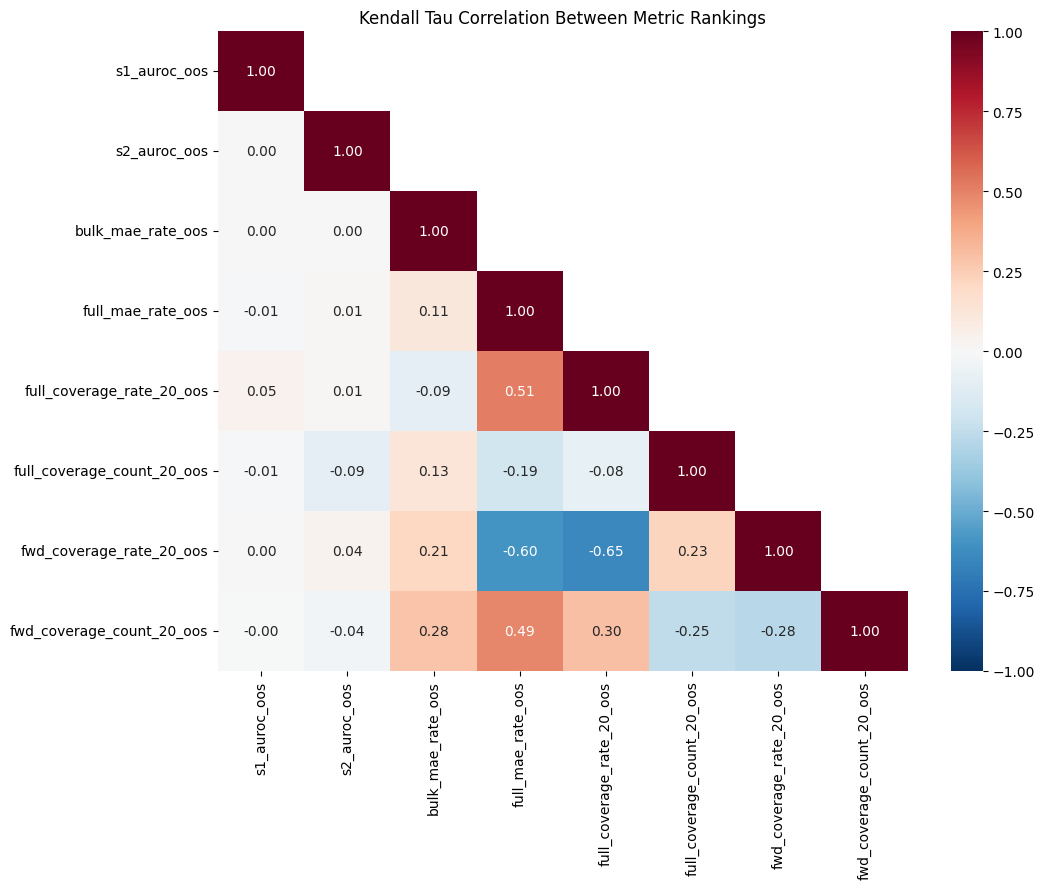


=== Metric Agreement Analysis ===
Average pairwise Kendall tau: 0.002
Pairs with negative correlation: 12
Low agreement. Flat top tier may be aggregation artifact (metric cancellation).


In [14]:
print(f'Computing rank correlations on {len(df_oos):,} configs × '
      f'{len(metrics_present)} metrics')
tau_df = kendall_tau_heatmap(df_oos, metrics_present, calib_present,
                              figsize=(11, 9))
plt.show()

## Winners by method

Borda → TOPSIS → Pareto frontier (first row) → pairwise dominance. Each
method picks one top config; the table compares them on a shared metric set.

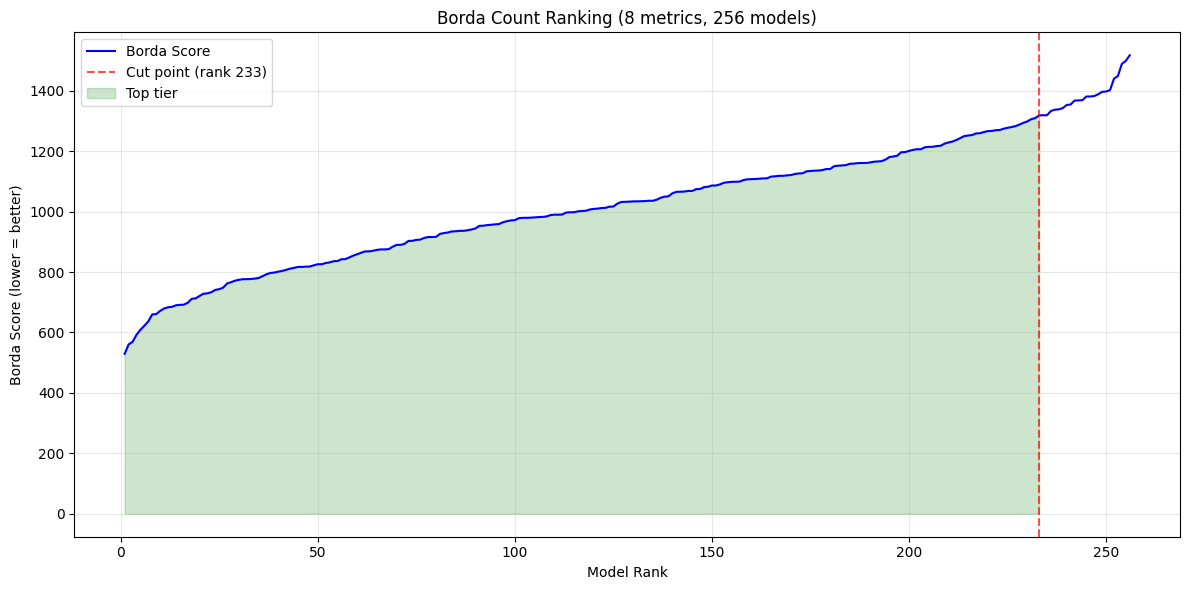


=== Borda Count Summary ===
Total models: 256
Metrics used: 8
Suggested cutpoint: rank 233 (top 233 models)
Top tier Borda range: 529.5 - 1318.5
Bottom tier starts at: 1319.0
   threshold_quantile   tail_family tail_exposure_mode bulk_exposure_mode  n_configs  median_rank  min_rank  max_rank  median_score
0                 0.7           gpd             weight               free         32        32.25       2.0     144.5        776.75
4                 0.7  log_logistic             weight               free         32        48.00       1.0     167.5        821.50
2                 0.7  log_logistic        free+weight               free         32        90.50      14.0     181.0        947.25
1                 0.7           gpd             weight        free+weight         30       139.50      38.0     233.0       1053.00
6                 0.7       weibull               free               free         30       141.50      35.0     212.0       1065.75
5                 0.7  log_logis

In [15]:
borda_df, _    = borda_rank(df_oos,    metrics_present, calib_present)
top_borda_df = borda_df[borda_df['borda_rank'] <= 233].copy()
# table of quantile, tail_family, and covariate configuration
summary_quality = (top_borda_df
    .groupby(['threshold_quantile', 'tail_family', 'tail_exposure_mode', 'bulk_exposure_mode'])
    .agg(
        n_configs=('borda_rank', 'count'),
        median_rank=('borda_rank', 'median'),
        min_rank=('borda_rank', 'min'),
        max_rank=('borda_rank', 'max'),
        median_score=('borda_score', 'median'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(summary_quality.to_string())

In [16]:
topsis_df, _   = topsis_rank(df_oos,   metrics_present, calib_present, verbose=False)
top_topsis_df = topsis_df[topsis_df['topsis_rank'] <= 200].copy()
summary_quality = (top_topsis_df
    .groupby(['threshold_quantile', 'tail_family', 'tail_exposure_mode', 'bulk_exposure_mode'])
    .agg(
        n_configs=('topsis_rank', 'count'),
        median_rank=('topsis_rank', 'median'),
        min_rank=('topsis_rank', 'min'),
        max_rank=('topsis_rank', 'max'),
        median_score=('topsis_score', 'median'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(summary_quality.to_string())

   threshold_quantile   tail_family tail_exposure_mode bulk_exposure_mode  n_configs  median_rank  min_rank  max_rank  median_score
4                 0.7  log_logistic             weight               free         32         60.5       1.0     181.0      0.603445
0                 0.7           gpd             weight               free         32         66.5       4.0     184.0      0.598696
2                 0.7  log_logistic        free+weight               free         32         66.5       3.0     178.0      0.599614
5                 0.7  log_logistic             weight        free+weight         24        117.0      22.0     196.0      0.551329
6                 0.7       weibull               free               free         25        122.0      24.0     200.0      0.549412
3                 0.7  log_logistic        free+weight        free+weight         22        124.5      20.0     191.0      0.545993
1                 0.7           gpd             weight        free+weight   

In [17]:
import json

def decode_cov_columns(df):
    for stage in ['s1', 's2', 'bulk', 'tail']:
        col = f'{stage}_cov'
        for cov in ['basin', 'is_island', 'sdi', 'wind_speed']:
            df[f'{stage}_{cov}'] = df[col].apply(
                lambda x: (x if isinstance(x, dict) else json.loads(x)).get(cov, False)
            )
    return df

top_topsis_df = decode_cov_columns(top_topsis_df)
top_borda_df = decode_cov_columns(top_borda_df)

In [20]:
# Decode cov JSON for each stage
import json

# Get the covariate pattern as a tuple for each stage
for stage in ['s1', 's2', 'bulk', 'tail']:
    covs = ['basin', 'is_island', 'sdi', 'wind_speed']
    top_topsis_df[f'{stage}_pattern'] = top_topsis_df.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']), axis=1
    )

# Summary by full covariate chain
chain_summary = (top_topsis_df
    .groupby(['s1_pattern', 's2_pattern', 'bulk_pattern', 'tail_pattern'])
    .agg(
        n=('topsis_rank', 'count'),
        median_rank=('topsis_rank', 'median'),
        min_rank=('topsis_rank', 'min'),
    )
    .reset_index()
    .sort_values('median_rank')
)
print(chain_summary.head(20).to_string())

                        s1_pattern                      s2_pattern          bulk_pattern tail_pattern  n  median_rank  min_rank
31            basin+sdi+wind_speed            basin+sdi+wind_speed        sdi+wind_speed          sdi  8         21.0       2.0
30            basin+sdi+wind_speed            basin+sdi+wind_speed        sdi+wind_speed               8         26.0       8.0
29            basin+sdi+wind_speed            basin+sdi+wind_speed                   sdi          sdi  8         31.5       1.0
28            basin+sdi+wind_speed            basin+sdi+wind_speed                   sdi               8         35.0       7.0
26            basin+sdi+wind_speed            basin+sdi+wind_speed  basin+sdi+wind_speed               8         56.5      19.0
27            basin+sdi+wind_speed            basin+sdi+wind_speed  basin+sdi+wind_speed          sdi  8         58.5       9.0
24            basin+sdi+wind_speed            basin+sdi+wind_speed             basin+sdi               8

## Picking table

Top configs by `topsis_rank`, with all stage covs / family-exposure
choices and the storm-level diagnostics in one place. Sort and filter
this table interactively — the pick rule is **not** baked in.

Columns of interest for the "no worse than any other" defense:
- `topsis_rank`               — composite rank on the metric pool
- `full_coverage_rate_*_oos`  — uncertainty coverage at chosen level
- `trim_n=*_oos_median`       — calibration robustness across drop-top-N
- `is_oos_max_log_dev`        — IS-to-OOS calibration transfer
- `oos_median_max_log_dev`    — calibration stability across the N sweep


In [28]:
df_oos.head()

,threshold_quantile,s1_family,s1_exposure_mode,s2_family,s2_exposure_mode,bulk_family,bulk_exposure_mode,tail_family,tail_exposure_mode,s1_cov,s2_cov,bulk_cov,tail_cov,s1_brier_oos,s1_auroc_oos,s1_fpr_oos,s1_fnr_oos,s1_predicted_positive_rate_oos,s2_brier_oos,s2_auroc_oos,s2_fpr_oos,s2_fnr_oos,s2_predicted_positive_rate_oos,bulk_mae_rate_oos,bulk_rmse_rate_oos,bulk_cor_rate_oos,bulk_mae_count_oos,bulk_rmse_count_oos,bulk_cor_count_oos,tail_mae_rate_oos,tail_rmse_rate_oos,tail_cor_rate_oos,tail_mae_count_oos,tail_rmse_count_oos,tail_cor_count_oos,fwd_mae_rate_oos,fwd_rmse_rate_oos,fwd_pred_obs_ratio_oos,fwd_coverage_rate_1_oos,fwd_coverage_count_1_oos,...,full_coverage_rate_14_oos,full_coverage_count_14_oos,full_coverage_rate_15_oos,full_coverage_count_15_oos,full_coverage_rate_16_oos,full_coverage_count_16_oos,full_coverage_rate_17_oos,full_coverage_count_17_oos,full_coverage_rate_18_oos,full_coverage_count_18_oos,full_coverage_rate_19_oos,full_coverage_count_19_oos,full_coverage_rate_20_oos,full_coverage_count_20_oos,cor_ts_oos,beta_0_ts_oos,beta_p_ts_oos,mid,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is,trim_n=0_oos_mean,trim_n=5_oos_mean,trim_n=10_oos_mean,trim_n=25_oos_mean,trim_n=0_oos_median,trim_n=5_oos_median,trim_n=10_oos_median,trim_n=25_oos_median,is_oos_ratio_n=0,is_oos_ratio_n=5,is_oos_ratio_n=10,is_oos_ratio_n=25,is_oos_max_log_dev,is_oos_mean_log_dev,oos_median_max_log_dev,oos_median_mean_log_dev,topsis_rank,topsis_score
0,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": false, ""is_island"": false, ""sdi"": tr...","{""basin"": false, ""is_island"": false, ""sdi"": fa...",0.16424,0.805163,0.127362,0.460198,0.265517,0.094798,0.919816,0.071336,0.282187,0.266341,2.355935e-07,3.759774e-07,0.561270,24.191888,71.333360,0.437221,0.000805,0.003187,-8.189454e-18,827.951120,4735.835444,0.571107,0.000249,0.002405,0.062397,0.057143,0.0,...,0.370787,0.439700,0.385315,0.452448,0.383607,0.470820,0.384568,0.475309,0.388338,0.488630,0.388398,0.492265,0.390551,0.501837,0.348822,-26824.479130,45.023222,7dbf251bad1f46546be3708689268710,0.097034,0.564157,0.735862,1.058651,0.099063,0.577353,0.753507,1.085325,0.098395,0.573257,0.748917,1.080958,0.986167,0.984126,0.982569,0.979364,0.020852,0.017092,2.318768,0.810541,13.0,0.676387
1,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": false, ""is_island"": false, ""sdi"": tr...","{""basin"": false, ""is_island"": false, ""sdi"": tr...",0.16424,0.805163,0.127362,0.460198,0.265517,0.094798,0.919816,0.071336,0.282187,0.266341,2.355935e-07,3.759774e-07,0.561270,24.191888,71.333360,0.437221,0.000805,0.003187,-5.391819e-02,830.124982,4735.927110,0.572082,0.000249,0.002405,0.064966,0.000000,0.0,...,0.376030,0.441948,0.389510,0.452448,0.386885,0.468197,0.389506,0.474074,0.400000,0.488047,0.402762,0.494475,0.401050,0.507087,0.354113,-25286.669301,41.715827,f5d317a21d7e7e2edfa4c3bdee42b79f,0.098330,0.571346,0.745051,1.070654,0.101965,0.594183,0.775543,1.115345,0.101324,0.590433,0.770615,1.105823,0.970455,0.967672,0.966827,0.968197,0.033736,0.032227,2.289434,0.794373,5.0,0.703606
2,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": false, ""is_island"": false, ""sdi"": tr...","{""basin"": false, ""is_island"": false, ""sdi"": fa...",0.16424,0.805163,0.127362,0.460198,0.265517,0.094798,0.919816,0.071336,0.282187,0.266341,2.365695e-07,3.781418e-07,0.556120,24.214820,71.329497,0.435530,0.000805,0.003187,-8.189454e-18,827.951120,4735.835444,0.571107,0.000249,0.002405,0.062561,0.057143,0.0,...,0.370037,0.436704,0.383916,0.448951,0.383607,0.469508,0.384568,0.475309,0.388338,0.489213,0.388398,0.493370,0.39055

In [21]:
# Attach topsis_rank back onto df_oos (if not already there from earlier cells).
if 'topsis_rank' not in df_oos.columns:
    df_oos = df_oos.merge(
        topsis_df[CONFIG_COLS + ['topsis_rank', 'topsis_score']],
        on=CONFIG_COLS, how='left',
    )

# Columns to show in the picking table.
picking_cols = [
    'mid', 'threshold_quantile',
    's1_family', 's1_exposure_mode', 's1_cov',
    's2_family', 's2_exposure_mode', 's2_cov',
    'bulk_family', 'bulk_exposure_mode', 'bulk_cov',
    'tail_family', 'tail_exposure_mode', 'tail_cov',
    'topsis_rank', 'topsis_score',
    'full_pred_obs_ratio_oos',
    'full_coverage_rate_5_oos', 'full_coverage_rate_10_oos',
    'full_coverage_rate_20_oos',
    'trim_n=0_oos_median',  'trim_n=5_oos_median',
    'trim_n=10_oos_median', 'trim_n=25_oos_median',
    'trim_n=0_is',  'trim_n=5_is', 'trim_n=10_is', 'trim_n=25_is',
    'oos_median_max_log_dev', 'is_oos_max_log_dev',
]
picking_cols = [c for c in picking_cols if c in df_oos.columns]

picking_df = (df_oos[picking_cols]
              .sort_values('topsis_rank')
              .reset_index(drop=True))

# Default view: top 15 by topsis_rank. Re-sort interactively to view by other
# columns (e.g., picking_df.sort_values('oos_median_max_log_dev').head(10)).
TOP_N = 15
print(f'Top {TOP_N} by topsis_rank ({len(picking_df)} configs total):')
print()
print(picking_df.head(TOP_N).round(3).to_string(index=False))


Top 15 by topsis_rank (256 configs total):

                             mid  threshold_quantile s1_family s1_exposure_mode                                                               s1_cov s2_family s2_exposure_mode                                                               s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov  tail_family tail_exposure_mode                                                                tail_cov  topsis_rank  topsis_score  full_pred_obs_ratio_oos  full_coverage_rate_5_oos  full_coverage_rate_10_oos  full_coverage_rate_20_oos  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  oos_median_max_log_dev  is_oos_max_log_dev
6004b730b8d8f96cb6d8443378b04f09                 0.7     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}     logit             free {"basin": tr

In [25]:
picking_df['tail_cov'].iloc[0]

'{"basin": false, "is_island": false, "sdi": true, "wind_speed": false}'

In [27]:
no_sdi_in_tail = picking_df[picking_df['tail_cov'] == '{"basin": false, "is_island": false, "sdi": false, "wind_speed": false}'].copy()
no_sdi_in_tail.head()

,mid,threshold_quantile,s1_family,s1_exposure_mode,s1_cov,s2_family,s2_exposure_mode,s2_cov,bulk_family,bulk_exposure_mode,bulk_cov,tail_family,tail_exposure_mode,tail_cov,topsis_rank,topsis_score,full_pred_obs_ratio_oos,full_coverage_rate_5_oos,full_coverage_rate_10_oos,full_coverage_rate_20_oos,trim_n=0_oos_median,trim_n=5_oos_median,trim_n=10_oos_median,trim_n=25_oos_median,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is,oos_median_max_log_dev,is_oos_max_log_dev
6,f5ead891bad7eee384d0f265199269b1,0.7,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": tr...",log_logistic,free+weight,"{""basin"": false, ""is_island"": false, ""sdi"": fa...",7.0,0.699200,0.105681,0.179167,0.282723,0.352756,0.104487,0.609531,0.795953,1.142626,0.101424,0.589511,0.769045,1.107025,2.258692,0.034390
7,568bbe5af22a6e4e54d435b5f8aff93c,0.7,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": tr...",log_logistic,free+weight,"{""basin"": false, ""is_island"": false, ""sdi"": fa...",8.0,0.697119,0.105475,0.179167,0.282723,0.353806,0.104185,0.607610,0.793528,1.138710,0.101189,0.588051,0.767015,1.103736,2.261592,0.033982
12,7dbf251bad1f46546be3708689268710,0.7,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": tr...",gpd,weight,"{""basin"": false, ""is_island"": false, ""sdi"": fa...",13.0,0.676387,0.099063,0.145833,0.307853,0.390551,0.098395,0.573257,0.748917,1.080958,0.097034,0.564157,0.735862,1.058651,2.318768,0.020852
13,81f715c5b0308e037a79047409c78aa9,0.7,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": tr...",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": fa...",14.0,0.675376,0.103617,0.141667,0.313089,0.388976,0.103382,0.602484,0.787297,1.131447,0.101693,0.591088,0.771016,1.109290,2.269327,0.020896
15,282e611d01bc8b8b6b6e6e1518e34207,0.7,logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",logit,free,"{""basin"": true, ""is_island"": false, ""sdi"": tru...",scaled_logit,free,"{""basin"": false, ""is_island"": false, ""sdi"": tr...",log_logistic,weight,"{""basin"": false, ""is_island"": false, ""sdi"": fa...",16.0,0.670279,0.103411,0.141667,0.310995,0.388976,0.103127,0.600903,0.784872,1.127530,0.101459,0.589628,0.768986,1.106001,2.271798,0.020448


In [31]:
cols = ['threshold_quantile',
        's1_family','s1_exposure_mode','s1_cov',
        's2_family','s2_exposure_mode','s2_cov',
        'bulk_family','bulk_exposure_mode','bulk_cov',
        'tail_family','tail_exposure_mode','tail_cov']
mids = ['6004b730b8d8f96cb6d8443378b04f09',   # best topsis  (model 1)
        '59f22b3e6c1ba66b0aa439dfa08eeb9a',   # 2nd topsis
        'f5ead891bad7eee384d0f265199269b1']   # best no-tail-cov
import pandas as pd
pd.set_option('display.max_colwidth', None)
for m in mids:
    r = df_oos[df_oos.mid == m].iloc[0]
    print(m)
    for c in ['s1_cov', 's2_cov', 'bulk_cov', 'tail_cov']:
        print('   ', c, '=', r[c])



6004b730b8d8f96cb6d8443378b04f09
    s1_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    s2_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    bulk_cov = {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}
    tail_cov = {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}
59f22b3e6c1ba66b0aa439dfa08eeb9a
    s1_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    s2_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    bulk_cov = {"basin": false, "is_island": false, "sdi": true, "wind_speed": true}
    tail_cov = {"basin": false, "is_island": false, "sdi": true, "wind_speed": false}
f5ead891bad7eee384d0f265199269b1
    s1_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    s2_cov = {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}
    bulk_cov = {"basin": false, "is_island": false, "sdi": true, "

In [23]:
# Alternate view: among the top-N by topsis_rank, re-sort by IS/OOS divergence
# to surface configs whose IS calibration transfers OOS most reliably.
N_SHORTLIST = 25
shortlist = picking_df.head(N_SHORTLIST).copy()
print(f'Among top {N_SHORTLIST} by topsis_rank, sorted by oos_median_max_log_dev:')
print()
print(shortlist
      .sort_values('oos_median_max_log_dev')
      .round(3)
      .to_string(index=False))


Among top 25 by topsis_rank, sorted by oos_median_max_log_dev:

                             mid  threshold_quantile s1_family s1_exposure_mode                                                               s1_cov s2_family s2_exposure_mode                                                               s2_cov  bulk_family bulk_exposure_mode                                                               bulk_cov  tail_family tail_exposure_mode                                                                tail_cov  topsis_rank  topsis_score  full_pred_obs_ratio_oos  full_coverage_rate_5_oos  full_coverage_rate_10_oos  full_coverage_rate_20_oos  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  oos_median_max_log_dev  is_oos_max_log_dev
e8cbc4cf10de116629b3569f1dcd4003                 0.7     logit             free {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}     logit          

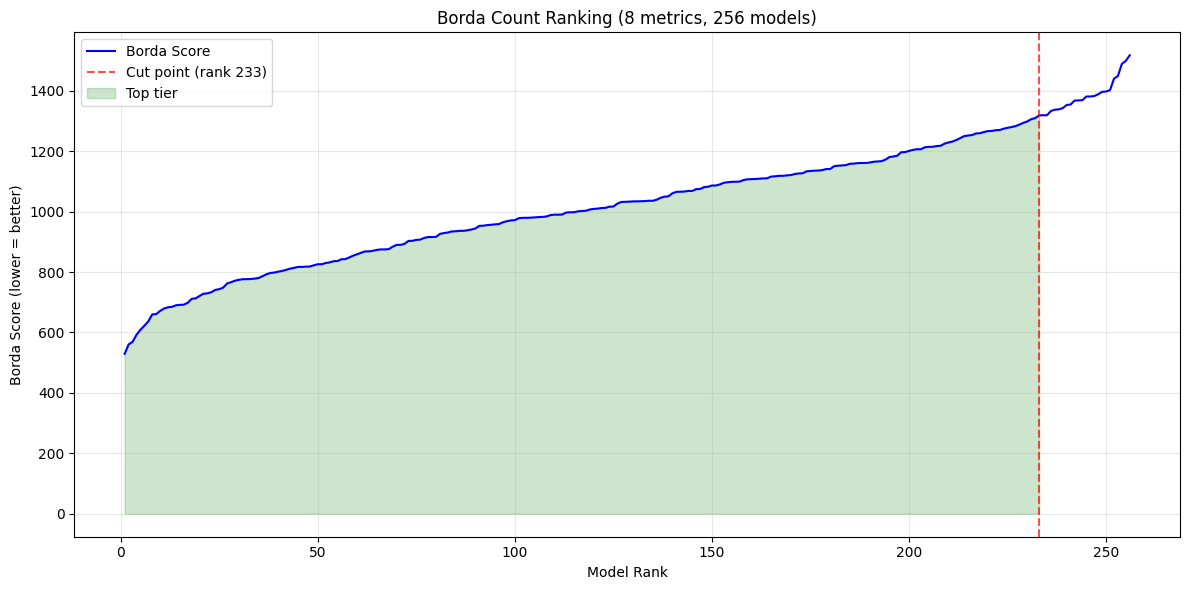


=== Borda Count Summary ===
Total models: 256
Metrics used: 8
Suggested cutpoint: rank 233 (top 233 models)
Top tier Borda range: 529.5 - 1318.5
Bottom tier starts at: 1319.0

=== Pareto Frontier ===
Total models: 256
Non-dominated: 128 (50.0%)
Dominated: 128


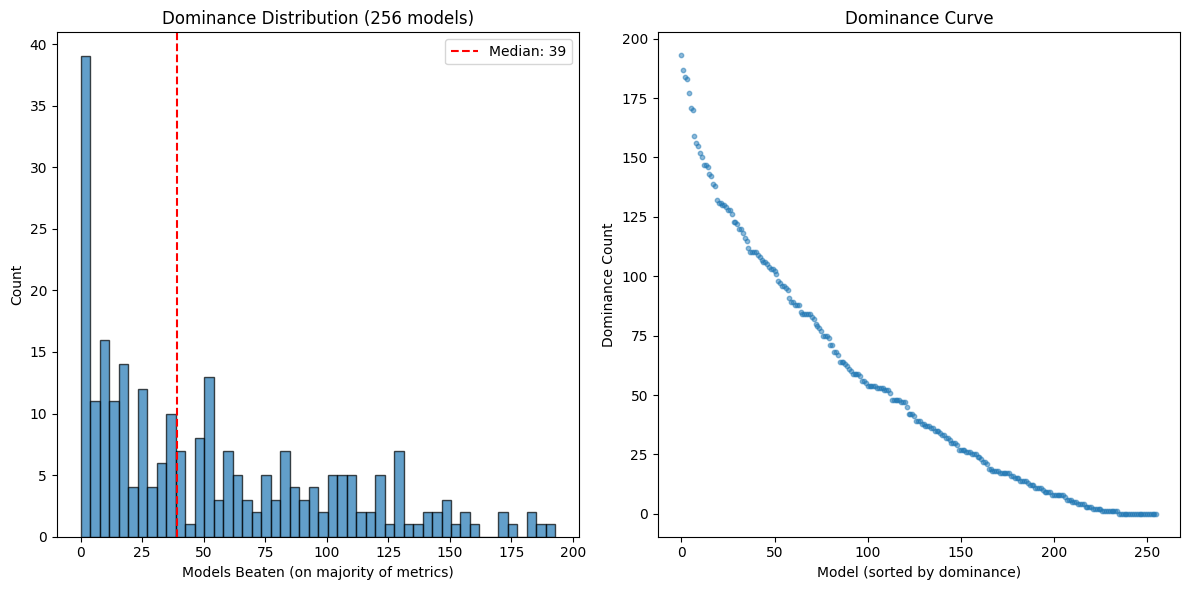


=== Pairwise Dominance Summary ===
Models compared: 256
Metrics used: 8
Max dominance: 193 / 255 models beaten
Median dominance: 39

Top 10 most dominant models:
   dominance_rank  dominance_count  dominance_pct  threshold_quantile s1_family s1_exposure_mode s2_family s2_exposure_mode   bulk_family bulk_exposure_mode   tail_family tail_exposure_mode                                                                s1_cov                                                                s2_cov                                                                bulk_cov                                                                tail_cov
0             1.0              193      75.686275                 0.7     logit             free     logit             free  scaled_logit               free  log_logistic             weight  {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}  {"basin": true, "is_island": false, "sdi": true, "wind_speed": true}  {"basin": false, "is_island": fa

In [24]:
borda_df, _    = borda_rank(df_oos,    metrics_present, calib_present)
topsis_df, _   = topsis_rank(df_oos,   metrics_present, calib_present, verbose=False)
pareto_df      = pareto_frontier(df_oos, metrics_present, calib_present)
dominance_df   = pairwise_dominance_summary(df_oos, metrics_present, calib_present)

winners = {
    'borda':              borda_df.iloc[0],
    'topsis':             topsis_df.iloc[0],
    'pareto_first':       pareto_df.iloc[0],
    'pairwise_dominance': dominance_df.iloc[0],
}
show_cols = [c for c in CONFIG_COLS if c in df_oos.columns] + [
    'full_mae_rate_oos', 'full_cor_rate_oos',
    'full_pred_obs_ratio_oos', 'full_coverage_rate_10_oos',
    'fwd_mae_rate_oos', 'fwd_coverage_rate_10_oos',
    's1_auroc_oos',
]


In [25]:
show_cols = [c for c in show_cols if c in df_oos.columns]
winners_df = pd.DataFrame({k: w[show_cols] for k, w in winners.items()}).T

def _active(j):
    return ','.join(k for k, v in json.loads(j).items() if v) or '∅'
for c in ('s1_cov', 's2_cov', 'bulk_cov', 'tail_cov'):
    if c in winners_df.columns:
        winners_df[c] = winners_df[c].map(_active)
winners_df

,threshold_quantile,s1_family,s1_exposure_mode,s2_family,s2_exposure_mode,bulk_family,bulk_exposure_mode,tail_family,tail_exposure_mode,s1_cov,s2_cov,bulk_cov,tail_cov,full_mae_rate_oos,full_cor_rate_oos,full_pred_obs_ratio_oos,full_coverage_rate_10_oos,fwd_mae_rate_oos,fwd_coverage_rate_10_oos,s1_auroc_oos
borda,0.7,logit,free,logit,free,scaled_logit,free,log_logistic,weight,"basin,sdi,wind_speed","basin,sdi,wind_speed",sdi,sdi,0.000084,-0.012894,0.107562,0.309948,0.000249,0.121875,0.805163
topsis,0.7,logit,free,logit,free,scaled_logit,free,log_logistic,weight,"basin,sdi,wind_speed","basin,sdi,wind_speed",sdi,sdi,0.000084,-0.012894,0.107562,0.309948,0.000249,0.121875,0.805163
pareto_first,0.7,logit,free,logit,free,scaled_logit,free,gpd,weight,"basin,sdi,wind_speed","basin,sdi,wind_speed",sdi,∅,0.000084,-0.019765,0.099063,0.307853,0.000249,0.121875,0.805163
pairwise_dominance,0.7,logit,free,logit,free,scaled_logit,free,log_logistic,weight,"basin,sdi,wind_speed","basin,sdi,wind_speed",sdi,sdi,0.000084,-0.012894,0.107562,0.309948,0.000249,0.121875,0.805163


In [26]:
top_borda_mid = borda_df['mid'].head(5)
top_topsis_mid = topsis_df['mid'].head(5)
top_mid = set(top_borda_mid) | set(top_topsis_mid)
print(top_mid)
print(len(top_mid))

{'fe66be97744ce18dc82d425fa88bdd92', '59f22b3e6c1ba66b0aa439dfa08eeb9a', '6004b730b8d8f96cb6d8443378b04f09', '1385cbc5186fb0063ee947b10a2104fb', '038fe819ac67cb2e29ac727a791e97d5', 'f5d317a21d7e7e2edfa4c3bdee42b79f'}
6


In [27]:
topsis_df.head(5)

,threshold_quantile,s1_family,s1_exposure_mode,s2_family,s2_exposure_mode,bulk_family,bulk_exposure_mode,tail_family,tail_exposure_mode,s1_cov,s2_cov,bulk_cov,tail_cov,s1_brier_oos,s1_auroc_oos,s1_fpr_oos,s1_fnr_oos,s1_predicted_positive_rate_oos,s2_brier_oos,s2_auroc_oos,s2_fpr_oos,s2_fnr_oos,s2_predicted_positive_rate_oos,bulk_mae_rate_oos,bulk_rmse_rate_oos,bulk_cor_rate_oos,bulk_mae_count_oos,bulk_rmse_count_oos,bulk_cor_count_oos,tail_mae_rate_oos,tail_rmse_rate_oos,tail_cor_rate_oos,tail_mae_count_oos,tail_rmse_count_oos,tail_cor_count_oos,fwd_mae_rate_oos,fwd_rmse_rate_oos,fwd_pred_obs_ratio_oos,fwd_coverage_rate_1_oos,fwd_coverage_count_1_oos,...,full_coverage_rate_14_oos,full_coverage_count_14_oos,full_coverage_rate_15_oos,full_coverage_count_15_oos,full_coverage_rate_16_oos,full_coverage_count_16_oos,full_coverage_rate_17_oos,full_coverage_count_17_oos,full_coverage_rate_18_oos,full_coverage_count_18_oos,full_coverage_rate_19_oos,full_coverage_count_19_oos,full_coverage_rate_20_oos,full_coverage_count_20_oos,cor_ts_oos,beta_0_ts_oos,beta_p_ts_oos,mid,trim_n=0_is,trim_n=5_is,trim_n=10_is,trim_n=25_is,trim_n=0_oos_mean,trim_n=5_oos_mean,trim_n=10_oos_mean,trim_n=25_oos_mean,trim_n=0_oos_median,trim_n=5_oos_median,trim_n=10_oos_median,trim_n=25_oos_median,is_oos_ratio_n=0,is_oos_ratio_n=5,is_oos_ratio_n=10,is_oos_ratio_n=25,is_oos_max_log_dev,is_oos_mean_log_dev,oos_median_max_log_dev,oos_median_mean_log_dev,topsis_rank,topsis_score
0,0.7,logit,free,logit,free,scaled_logit,free,log_logistic,weight,"{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": false, ""is_island"": false, ""sdi"": tr...","{""basin"": false, ""is_island"": false, ""sdi"": tr...",0.16424,0.805163,0.127362,0.460198,0.265517,0.094798,0.919816,0.071336,0.282187,0.266341,2.355935e-07,3.759774e-07,0.56127,24.191888,71.333360,0.437221,0.000805,0.003187,-0.045190,831.052674,4735.014672,0.571676,0.000249,0.002405,0.068652,0.000000,0.0,...,0.373034,0.446442,0.385315,0.451748,0.389508,0.467541,0.391358,0.475309,0.401166,0.488630,0.401105,0.494475,0.402100,0.509711,0.355257,-24794.747377,38.918724,6004b730b8d8f96cb6d8443378b04f09,0.103597,0.601750,0.784714,1.127637,0.107562,0.626790,0.818167,1.175917,0.106312,0.619170,0.808306,1.158754,0.974469,0.971866,0.970813,0.973146,0.029621,0.027810,2.241380,0.770229,1.0,0.718548
1,0.7,logit,free,logit,free,scaled_logit,free,log_logistic,weight,"{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": false, ""is_island"": false, ""sdi"": tr...","{""basin"": false, ""is_island"": false, ""sdi"": tr...",0.16424,0.805163,0.127362,0.460198,0.265517,0.094798,0.919816,0.071336,0.282187,0.266341,2.365695e-07,3.781418e-07,0.55612,24.214820,71.329497,0.435530,0.000805,0.003187,-0.045190,831.052674,4735.014672,0.571676,0.000249,0.002405,0.068816,0.000000,0.0,...,0.373783,0.444944,0.384615,0.448951,0.389508,0.468197,0.391358,0.474691,0.400583,0.489796,0.401657,0.497238,0.402100,0.508661,0.353927,-24688.691309,38.866202,59f22b3e6c1ba66b0aa439dfa08eeb9a,0.103363,0.600290,0.782684,1.124349,0.107356,0.625491,0.816406,1.172911,0.106009,0.617249,0.805881,1.154837,0.975040,0.972526,0.971215,0.973599,0.029208,0.027275,2.244230,0.771623,2.0,0.712419
2,0.7,logit,free,logit,free,scaled_logit,free,log_logistic,free+weight,"{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": true, ""is_island"": false, ""sdi"": tru...","{""basin"": false, ""is_island"": false, ""sdi"": tr...","{""basin"": false, ""is_island"": false, ""sdi"": tr...",0.16424,0.805163,0.127362,0.460198,0.265517,0.094798,0.919816,0.071336,0.282187,0.266341,2.355935e-07,3.759774e-07,0.56127,24.191888,71.333360,0.437221,0.000804,0.003186,0.096425,834.172856,4746.246884,0.564117,0.000249,0.002405,0.070846,0.057143,0.0,...,0.357303,0.445693,0.369231,0.453147,0.373115,0.470164,0.377778,0.475309,0.388921,0.489796,0.390608,0

In [28]:
import json

def decode_cov_columns(df):
    df = df.copy()
    for stage in ['s1', 's2', 'bulk', 'tail']:
        col = f'{stage}_cov'
        for cov in ['basin', 'is_island', 'sdi', 'wind_speed']:
            df[f'{stage}_{cov}'] = df[col].apply(
                lambda x: (x if isinstance(x, dict) else json.loads(x)).get(cov, False)
            )
    return df

covs = ['basin', 'is_island', 'sdi', 'wind_speed']
df_oos = decode_cov_columns(df_oos)
for stage in ['s1', 's2', 'bulk', 'tail']:
    df_oos[f'{stage}_pattern'] = df_oos.apply(
        lambda row: '+'.join(c for c in covs if row[f'{stage}_{c}']) or '∅',
        axis=1,
    )


In [29]:
top_df = df_oos[df_oos['mid'].isin(top_mid)].copy()
top_df['mid_short'] = top_df['mid'].str[:8]


display_cols = [
    'mid_short', 'topsis_rank', 'topsis_score',
    'threshold_quantile',
    's1_family',   's1_exposure_mode',   's1_pattern',
    's2_family',   's2_exposure_mode',   's2_pattern',
    'bulk_family', 'bulk_exposure_mode', 'bulk_pattern',
    'tail_family', 'tail_exposure_mode', 'tail_pattern',
    'full_pred_obs_ratio_oos',
    'full_coverage_rate_5_oos', 'full_coverage_rate_10_oos', 'full_coverage_rate_20_oos',
    'trim_n=0_oos_median', 'trim_n=5_oos_median', 'trim_n=10_oos_median', 'trim_n=25_oos_median',
    'trim_n=0_is',  'trim_n=5_is',  'trim_n=10_is',  'trim_n=25_is',
    'oos_median_max_log_dev', 'is_oos_max_log_dev',
]
display_cols = [c for c in display_cols if c in top_df.columns]

top_df_view = (
    top_df[display_cols]
    .sort_values('topsis_rank')
    .reset_index(drop=True)
    .round(3)
)

# Set display width for the notebook so it doesn't wrap awkwardly.
import pandas as pd
with pd.option_context('display.max_columns', None,
                       'display.width', 220,
                       'display.max_colwidth', 30):
    print(top_df_view.to_string(index=False))


mid_short  topsis_rank  topsis_score  threshold_quantile s1_family s1_exposure_mode           s1_pattern s2_family s2_exposure_mode                     s2_pattern  bulk_family bulk_exposure_mode   bulk_pattern  tail_family tail_exposure_mode tail_pattern  full_pred_obs_ratio_oos  full_coverage_rate_5_oos  full_coverage_rate_10_oos  full_coverage_rate_20_oos  trim_n=0_oos_median  trim_n=5_oos_median  trim_n=10_oos_median  trim_n=25_oos_median  trim_n=0_is  trim_n=5_is  trim_n=10_is  trim_n=25_is  oos_median_max_log_dev  is_oos_max_log_dev
 6004b730          1.0         0.719                 0.7     logit             free basin+sdi+wind_speed     logit             free           basin+sdi+wind_speed scaled_logit               free            sdi log_logistic             weight          sdi                    0.108                     0.144                      0.310                      0.402                0.106                0.619                 0.808                 1.159        0.1